In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import DiadFit as pf
pf.__version__

'1.0.11'

## Lets load in all the power series. 

In [13]:


df= pd.read_excel(r'C:\Users\penny\Box\Berkeley_new\Raman\Raman technical paper\Supporting_Info\Supporting_information_Draft1.xlsx',
                          sheet_name='power_series')

df_16=df.loc[df['filename'].str.contains('FG04-A11-16')]
df_9=df.loc[df['filename'].str.contains('FG04-A11-9')]
df_21=df.loc[df['filename'].str.contains('ML22_77_4_MIA')]

In [20]:
df_21=df_21.loc[df_21['σ Density g/cm3']>0]

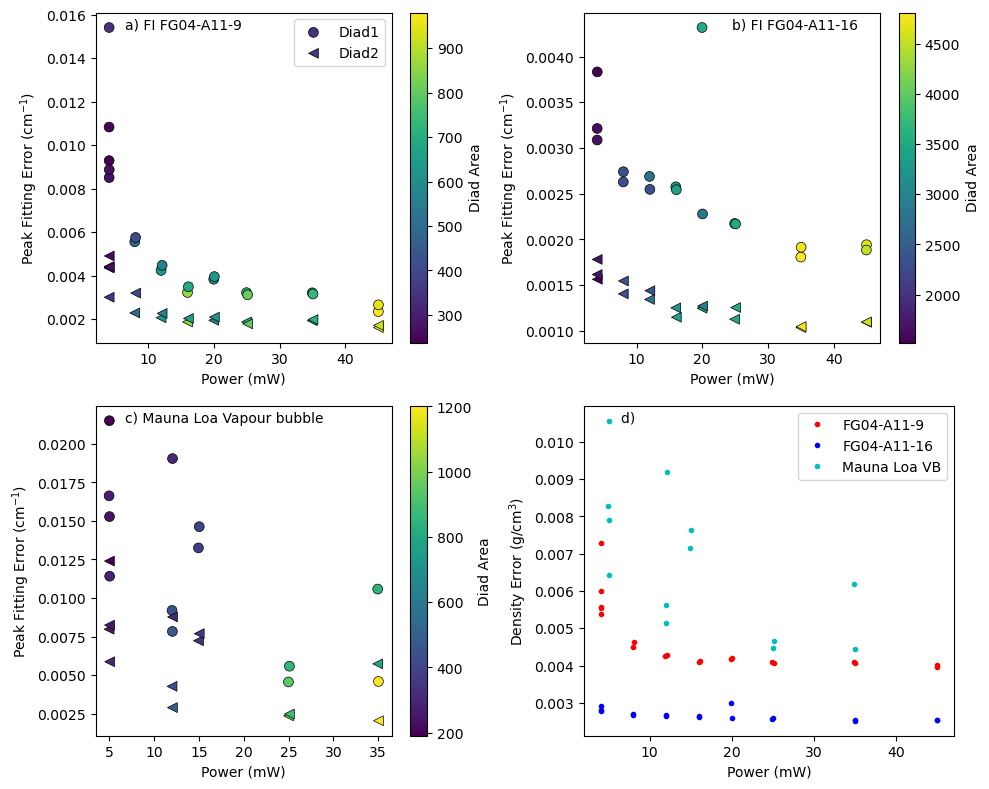

In [21]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2,2, figsize = (10,8))

s=ax1.scatter(x=df_9['power (mW)'],
          y=df_9['Diad1_cent_err'], marker='o', s=50, edgecolors='k', linewidths=0.5,
            c=df_9['Diad1_Voigt_Area'], cmap='viridis', label='Diad1')

s=ax1.scatter(x=df_9['power (mW)'],
          y=df_9['Diad2_cent_err'], marker='<', s=50, edgecolors='k', linewidths=0.5,
            c=df_9['Diad2_Voigt_Area'], cmap='viridis',  label='Diad2')
fig.colorbar(s, ax=ax1, label='Diad Area')
ax1.set_xlabel('Power (mW)')
ax1.set_ylabel('Peak Fitting Error (cm$^{-1}$)')

ax1.annotate("a) FI FG04-A11-9 ", xy=(0.1, 0.95), xycoords="axes fraction", fontsize=10)
ax1.legend()

##########################
s=ax2.scatter(x=df_16['power (mW)'],
          y=df_16['Diad1_cent_err'], marker='o', s=50, edgecolors='k', linewidths=0.5,
            c=df_16['Diad1_Voigt_Area'], cmap='viridis')

s=ax2.scatter(x=df_16['power (mW)'],
          y=df_16['Diad2_cent_err'], marker='<', s=50, edgecolors='k', linewidths=0.5,
            c=df_16['Diad2_Voigt_Area'], cmap='viridis')
fig.colorbar(s, ax=ax2, label='Diad Area')
ax2.set_xlabel('Power (mW)')
ax2.set_ylabel('Peak Fitting Error (cm$^{-1}$)')

ax2.annotate("b) FI FG04-A11-16 ", xy=(0.5, 0.95), xycoords="axes fraction", fontsize=10)

##################3

s=ax3.scatter(x=df_21['power (mW)'],
          y=df_21['Diad1_cent_err'], marker='o', s=50, edgecolors='k', linewidths=0.5,
            c=df_21['Diad1_Voigt_Area'], cmap='viridis')

s=ax3.scatter(x=df_21['power (mW)'],
          y=df_21['Diad2_cent_err'], marker='<', s=50, edgecolors='k', linewidths=0.5,
            c=df_21['Diad2_Voigt_Area'], cmap='viridis')
fig.colorbar(s, ax=ax3, label='Diad Area')
ax3.set_xlabel('Power (mW)')
ax3.set_ylabel('Peak Fitting Error (cm$^{-1}$)')

ax3.annotate("c) Mauna Loa Vapour bubble ", xy=(0.1, 0.95), xycoords="axes fraction", fontsize=10)

## Lets show them all for context

# ax4.plot(df_9['power (mW)'], 100*df_9['σ Density g/cm3']/df_9['Density g/cm3'].iloc[0], '.r')
# ax4.plot(df_21['power (mW)'], 100*df_21['σ Density g/cm3']/df_21['Density g/cm3'].iloc[0], '.b')
# ax4.plot(df_16['power (mW)'], 100*df_16['σ Density g/cm3']/df_16['Density g/cm3'].iloc[0], '.c')

ax4.plot(df_9['power (mW)'],df_9['σ Density g/cm3'], '.r', label='FG04-A11-9')
ax4.plot(df_16['power (mW)'], df_16['σ Density g/cm3'], '.b', label='FG04-A11-16')
ax4.plot(df_21['power (mW)'], df_21['σ Density g/cm3'], '.c', label='Mauna Loa VB')
ax4.legend()

ax4.annotate("d) ", xy=(0.1, 0.95), xycoords="axes fraction", fontsize=10)


fig.tight_layout()
ax4.set_xlabel('Power (mW)')
ax4.set_ylabel('Density Error (g/cm$^{3}$)')
fig.savefig('Errors_laser_power.png', dpi=200)

In [7]:
df_9

,Unnamed: 0,filename,Density g/cm3,σ Density g/cm3,σ Density g/cm3 (from Ne+peakfit),σ Density g/cm3 (from densimeter),Corrected_Splitting,Corrected_Splitting_σ,Corrected_Splitting_σ_Ne,Corrected_Splitting_σ_peak_fit,...,Int_time (s),accumulations,Mag (X),duration,24hr_time,sec since midnight,time,preferred_values,lower_values,upper_values
0,0,FG04-A11-9-4mW-1,0.120687,0.007298,0.006213,0.003829,103.054836,0.015681,0.000536,0.015707,...,45,5,40,"['0h', '3m', '47s']",11:07:40 AM\n,40060,40060,0.997751,0.997745,0.997756
1,1,FG04-A11-9-4mW-1re,0.114888,0.005584,0.004073,0.003820,103.040200,0.010279,0.000534,0.010288,...,45,5,40,"['0h', '3m', '46s']",11:11:54 AM\n,40314,40314,0.997748,0.997743,0.997753
2,2,FG04-A11-9-4mW-1re2,0.123675,0.006005,0.004621,0.003834,103.062377,0.011662,0.000533,0.011676,...,45,5,40,"['0h', '3m', '46s']",11:16:08 AM\n,40568,40568,0.997745,0.997740,0.997750
3,3,FG04-A11-9-8mW-1,0.116594,0.004505,0.002384,0.003822,103.044508,0.006016,0.000530,0.006006,...,45,5,40,"['0h', '3m', '46s']",11:24:27 AM\n,41067,41067,0.997738,0.997733,0.997743
4,4,FG04-A11-9-12mW-1,0.109208,0.004249,0.001875,0.003813,103.025866,0.004731,0.000528,0.004712,...,45,5,40,"['0h', '3m', '46s']",11:30:14 AM\n,41414,41414,0.997733,0.997728,0.997738
5,5,FG04-A11-9-16mW-1,0.106470,0.004090,0.001486,0.003810,103.018956,0.003751,0.000526,0.003723,...,45,5,40,"['0h', '3m', '46s']",11:36:00 AM\n,41760,41760,0.997727,0.997722,0.997732
6,6,FG04-A11-9-20mW-1,0.114547,0.004185,0.001711,0.003820,103.039340,0.004319,0.000524,0.004297,...,30,5,40,"['0h', '2m', '32s']",11:43:27 AM\n,42207,42207,0.997718,0.997713,0.997723
7,7,FG04-A11-9-25mW-1,0.103404,0.004087,0.001485,0.003807,103.011219,0.003748,0.000524,0.003720,...,30,5,40,"['0h', '2m', '31s']",11:46:19 AM\n,42379,42379,0.997715,0.997710,0.997720
8,8,FG04-A11-9-35mW-1,0.104868,0.004091,0.001494,0.003809,103.014912,0.003769,0.000523,0.003741,...,20,5,40,"['0h', '1m', '42s']",11:49:03 AM\n,42543,42543,0.997712,0.997707,0.997717
9,9,FG04-A11-9-45mW-1,0.102483,0.003975,0.001144,0.003807,103.008894,0.002886,0.000522,0.002845,...,20,5,40,"['0h', '1m', '42s']",11:54:20 AM\n,42860,42860,0.997705,0.997700,0.997710


In [8]:
ax1.plot(df['power (mW)'], df['Diad2_cent_err'], '.b')

ax2.plot(df['power (mW)'], df['Diad1_Voigt_Area'], '.r')

In [9]:
df_9.columns

Index(['Unnamed: 0', 'filename', 'Density g/cm3', 'σ Density g/cm3',
       'σ Density g/cm3 (from Ne+peakfit)',
       'σ Density g/cm3 (from densimeter)', 'Corrected_Splitting',
       'Corrected_Splitting_σ', 'Corrected_Splitting_σ_Ne',
       'Corrected_Splitting_σ_peak_fit', 'power (mW)', 'Spectral Center',
       'Preferred D_σ_Ne', 'Preferred D_σ_pkfit', 'in range', 'Notes',
       'LowD_RT', 'HighD_RT', 'LowD_SC', 'LowD_SC_σ', 'MedD_SC', 'MedD_SC_σ',
       'HighD_SC', 'HighD_SC_σ', 'Temperature', 'Splitting', 'Split_σ',
       'Diad1_Combofit_Cent', 'Diad1_cent_err', 'Diad1_Combofit_Height',
       'Diad1_Voigt_Cent', 'Diad1_Voigt_Area', 'Diad1_Voigt_Sigma',
       'Diad1_Residual', 'Diad1_Prop_Lor', 'Diad1_fwhm', 'Diad1_refit',
       'Diad2_Combofit_Cent', 'Diad2_cent_err', 'Diad2_Combofit_Height',
       'Diad2_Voigt_Cent', 'Diad2_Voigt_Area', 'Diad2_Voigt_Sigma',
       'Diad2_Voigt_Gamma', 'Diad2_Residual', 'Diad2_Prop_Lor', 'Diad2_fwhm',
       'Diad2_refit', 'HB1_Cent',

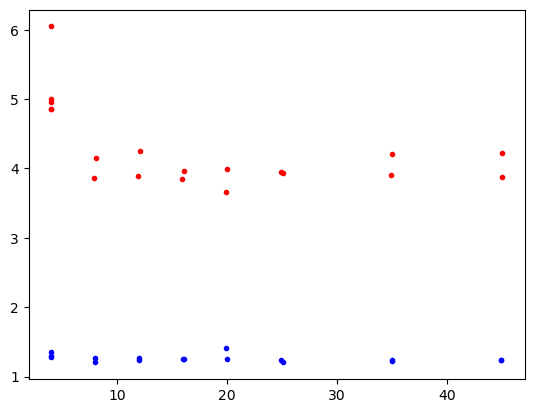

In [10]:
plt.plot(df_9['power (mW)'], 100*df_9['σ Density g/cm3']/df_9['Density g/cm3'], '.r')
plt.plot(df_16['power (mW)'], 100*df_16['σ Density g/cm3']/df_16['Density g/cm3'], '.b')

[]

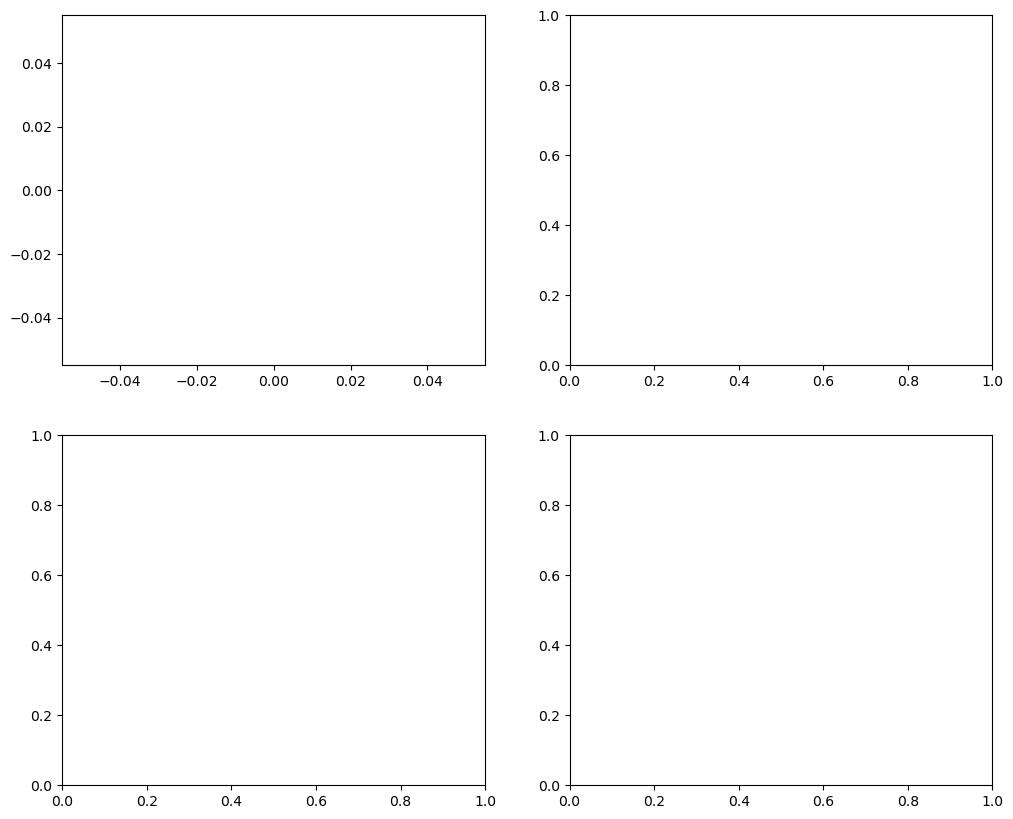

In [11]:
fig, ((ax0, ax1), (ax2, ax3)) = plt.subplots(2,2, figsize = (12,10))

ax0.plot()